I figured it gets stuck because we get the wrong coeffs; what if we do weighted least squares with the weights equal to 1 / mse_i?

In [1]:
# %% Imports
from jax import random, numpy as jnp

from modax.data.kdv import DoubleSoliton
from modax.models import DeepmodBayes
from flax import optim
from modax.losses.bayesian import loss_fn_mse_precalc
from modax.training import train_probabilistic_mse
from conditional_gaussian import *


import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

In [2]:
# %% Making data
key = random.PRNGKey(42)

x = jnp.linspace(-10, 10, 100)
t = jnp.linspace(0.1, 1.0, 10)
t_grid, x_grid = jnp.meshgrid(t, x, indexing="ij")

u = DoubleSoliton(x_grid, t_grid, c=[5.0, 2.0], x0=[0.0, -5.0])

X = jnp.concatenate([t_grid.reshape(-1, 1), x_grid.reshape(-1, 1)], axis=1)
y = u.reshape(-1, 1)
y += 0.1 * jnp.std(y) * random.normal(key, y.shape)

In [3]:
model = DeepmodBayes([30, 30, 30, 1])
variables = model.init(key, X)

optimizer = optim.Adam(learning_rate=2e-3, beta1=0.99, beta2=0.99)
state, params = variables.pop("params")
optimizer = optimizer.create(params)

In [4]:
# only train mse, stop at minimum mse testset
optimizer, state = train_probabilistic_mse(
    model,
    optimizer,
    state,
    loss_fn_mse_precalc,
    X,
    y,
    max_epochs=1e4,
    split=0.8,
    rand_seed=42,
)

Loss step 0.0: 214.76449584960938
Loss step 1000.0: -301.2978210449219
Loss step 2000.0: -346.8804016113281
Loss step 3000.0: -402.6247863769531
Loss step 4000.0: -430.0385437011719
Loss step 5000.0: -476.61474609375


In [5]:
variables = {"params": optimizer.target, **state}
prediction, dt, theta, coeffs, _ = model.apply(variables, X, mutable=list(state.keys()))[0]

Least squares coeffs results in:

In [6]:
coeffs

DeviceArray([[ 0.03994345],
             [-1.1709888 ],
             [-0.28332233],
             [-0.5694984 ],
             [-0.20667218],
             [-5.5566745 ],
             [ 0.63911057],
             [ 0.46550128],
             [ 0.22693199],
             [ 1.7800659 ],
             [-0.18755127],
             [-0.09182122]], dtype=float32)

Now let's do weighted least squares. Let's normalize the weight matrix by the variance:

In [7]:
w =  jnp.diag((jnp.var(y - prediction) / (prediction - y)**2).squeeze())

In [8]:
X_prime = jnp.sqrt(w) @ theta
y_prime = jnp.sqrt(w) @ dt

In [9]:
jnp.linalg.lstsq(X_prime, y_prime)

(DeviceArray([[ 0.06664974],
              [-0.16816378],
              [-0.44390738],
              [-1.2250159 ],
              [-0.24219751],
              [-8.023652  ],
              [-0.8359305 ],
              [ 1.3848853 ],
              [ 0.7269475 ],
              [ 2.782598  ],
              [ 0.57661986],
              [-0.36273175]], dtype=float32),
 DeviceArray([17697.8], dtype=float32),
 DeviceArray(12, dtype=int32),
 DeviceArray([5678.78    , 3054.3386  , 2482.9185  ,  909.9324  ,
               446.68265 ,  372.85092 ,  331.31766 ,  186.03653 ,
               120.402565,   72.3704  ,   41.55005 ,   21.951597],            dtype=float32))

In [10]:
jnp.linalg.lstsq(theta, dt)

(DeviceArray([[ 0.03994345],
              [-1.1709888 ],
              [-0.28332233],
              [-0.5694984 ],
              [-0.20667218],
              [-5.5566745 ],
              [ 0.63911057],
              [ 0.46550128],
              [ 0.22693199],
              [ 1.7800659 ],
              [-0.18755127],
              [-0.09182122]], dtype=float32),
 DeviceArray([206.37802], dtype=float32),
 DeviceArray(12, dtype=int32),
 DeviceArray([685.96704  , 200.37038  ,  64.1665   ,  38.142887 ,
               35.849815 ,  21.676744 ,  18.036333 ,  12.123935 ,
                8.954225 ,   4.303214 ,   3.1248071,   1.4660981],            dtype=float32))

Which is remarkably good. In the normal case, W is an identity matrix, so what if we normalize with that?

In [11]:
w =  1 /  (prediction - y)**2
w = jnp.diag((w / jnp.sum(w) * prediction.shape[0]).squeeze())

In [12]:
X_prime = jnp.sqrt(w) @ theta
y_prime = jnp.sqrt(w) @ dt

In [13]:
jnp.linalg.lstsq(X_prime, y_prime)

(DeviceArray([[ 0.06664994],
              [-0.16816545],
              [-0.44390953],
              [-1.225015  ],
              [-0.24219596],
              [-8.023643  ],
              [-0.8359275 ],
              [ 1.3848832 ],
              [ 0.7269455 ],
              [ 2.782596  ],
              [ 0.5766187 ],
              [-0.36273104]], dtype=float32),
 DeviceArray([2.275955], dtype=float32),
 DeviceArray(12, dtype=int32),
 DeviceArray([64.39872   , 34.63693   , 28.15689   , 10.318852  ,
               5.0654902 ,  4.228219  ,  3.757222  ,  2.1096992 ,
               1.3653948 ,  0.8206977 ,  0.47118783,  0.24893664],            dtype=float32))

In [14]:
coeffs = jnp.linalg.lstsq(X_prime, y_prime)[0]

jnp.mean((y_prime - X_prime @ coeffs)**2)

DeviceArray(0.00227595, dtype=float32)

Let's check if our algo works by setting W = eye.

In [15]:
w = jnp.eye(prediction.shape[0])

In [16]:
X_prime = jnp.sqrt(w) @ theta
y_prime = jnp.sqrt(w) @ dt

In [17]:
jnp.linalg.lstsq(X_prime, y_prime)

(DeviceArray([[ 0.03994345],
              [-1.1709888 ],
              [-0.28332233],
              [-0.5694984 ],
              [-0.20667218],
              [-5.5566745 ],
              [ 0.63911057],
              [ 0.46550128],
              [ 0.22693199],
              [ 1.7800659 ],
              [-0.18755127],
              [-0.09182122]], dtype=float32),
 DeviceArray([206.37802], dtype=float32),
 DeviceArray(12, dtype=int32),
 DeviceArray([685.96704  , 200.37038  ,  64.1665   ,  38.142887 ,
               35.849815 ,  21.676744 ,  18.036333 ,  12.123935 ,
                8.954225 ,   4.303214 ,   3.1248071,   1.4660981],            dtype=float32))

In [18]:
w = jnp.eye(prediction.shape[0])
print(w.sum())

1000.0


In [19]:
w =  1 /  (prediction - y)**2
w = jnp.diag((w / jnp.sum(w) * prediction.shape[0]).squeeze())

print(w.sum())

999.9998


now what if we calculate the coeffs on the correct set, then use those coeffs for the wrong set?

In [20]:
w =  jnp.minimum(jnp.var((prediction - y)) /  (prediction - y)**2, 1.0).squeeze()
X_prime = jnp.sqrt(jnp.diag(w)) @ theta
y_prime = jnp.sqrt(jnp.diag(w)) @ dt
jnp.linalg.lstsq(X_prime, y_prime)

(DeviceArray([[ 0.03993675],
              [-0.93109155],
              [-0.31872368],
              [-0.61738634],
              [-0.12787801],
              [-5.908205  ],
              [ 0.73868406],
              [ 0.49871624],
              [ 0.21161869],
              [ 1.8954394 ],
              [-0.21635295],
              [-0.09675281]], dtype=float32),
 DeviceArray([158.84259], dtype=float32),
 DeviceArray(12, dtype=int32),
 DeviceArray([577.83417  , 177.7972   ,  56.333477 ,  35.46945  ,
               32.68914  ,  19.820692 ,  16.406233 ,  11.239708 ,
                8.010264 ,   3.8209107,   2.8914716,   1.3047103],            dtype=float32))

In [57]:
coeffs = jnp.linalg.lstsq(X_prime, y_prime)[0]
jnp.mean((dt - theta @ coeffs)**2)

DeviceArray(0.00859335, dtype=float32)

In [58]:
coeffs

DeviceArray([[ 0.02505355],
             [-0.06827873],
             [-0.48402768],
             [-0.9163871 ],
             [ 0.33898953],
             [-5.929938  ],
             [ 0.8986265 ],
             [-0.08747154],
             [-0.23293805],
             [-0.42845082],
             [-0.30697784],
             [-0.04479106]], dtype=float32)

In [64]:
ridge(X_prime, y_prime, 1e-5)

DeviceArray([[ 0.0124793 ],
             [-0.5848857 ],
             [-0.37796918],
             [-0.7250242 ],
             [ 0.37704745],
             [-4.2912745 ],
             [ 0.8480469 ],
             [-0.19957775],
             [-0.24988636],
             [-1.3645903 ],
             [-0.3058223 ],
             [-0.07193883]], dtype=float32)

that could work....

Now lets write the loss function, first for a normal pinn:

In [28]:
from modax.losses.utils import mse

In [ ]:
def loss_fn_pinn_weighted(params, state, model, x, y):
    variables = {"params": params, **state}
    (prediction, dt, theta, coeffs, z), updated_state = model.apply(
        variables, x, mutable=list(state.keys())
    )
    
    w =  jnp.minimum(jnp.var((prediction - y)) /((prediction - y)**2 + 1e-6), 1.0)
    w = jnp.diag(w.squeeze())
    X_prime = jnp.sqrt(w) @ theta
    y_prime = jnp.sqrt(w) @ dt
    weighted_coeffs = jnp.linalg.lstsq(X_prime, y_prime)[0]

    MSE = mse(prediction, y)
    Reg = mse(dt, theta @ weighted_coeffs)
    loss = MSE + Reg
    metrics = {"loss": loss, "mse": MSE, "reg": Reg, "coeff": coeffs, "weighted_coeffs": weighted_coeffs}

    return loss, (updated_state, metrics, (prediction, dt, theta, coeffs))

In [33]:
model = DeepmodBayes([30, 30, 30, 1])
variables = model.init(key, X)

optimizer = optim.Adam(learning_rate=1e-3, beta1=0.99, beta2=0.99)
state, params = variables.pop("params")
optimizer = optimizer.create(params)

In [34]:
# only train mse, stop at minimum mse testset
optimizer, state = train_probabilistic_mse(
    model,
    optimizer,
    state,
    loss_fn_pinn_weighted,
    X,
    y,
    max_epochs=1e4,
    split=0.8,
    rand_seed=42,
)

Loss step 0.0: 0.502236545085907
Loss step 1000.0: 0.019139230251312256
Loss step 2000.0: 0.0031824626494199038
Loss step 3000.0: 0.003137234365567565
Loss step 4000.0: 0.003113715210929513
Loss step 5000.0: 0.0030930712819099426
Loss step 6000.0: 0.003078311216086149


In [35]:
variables = {"params": optimizer.target, **state}
prediction, dt, theta, coeffs, _ = model.apply(variables, X, mutable=list(state.keys()))[0]

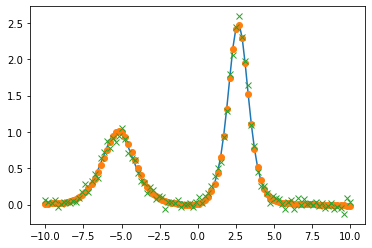

In [41]:
frame = 3
plt.plot(x, u[frame, :])
plt.plot(x, prediction.reshape(x_grid.shape)[frame, :], 'o')
plt.plot(x, y.reshape(x_grid.shape)[frame, :], 'x')

In [42]:
def loss_fn_pinn(params, state, model, x, y):
    variables = {"params": params, **state}
    (prediction, dt, theta, coeffs, z), updated_state = model.apply(
        variables, x, mutable=list(state.keys())
    )
    

    MSE = mse(prediction, y)
    Reg = mse(dt, theta @ coeffs)
    loss = MSE + Reg
    metrics = {"loss": loss, "mse": MSE, "reg": Reg, "coeff": coeffs}

    return loss, (updated_state, metrics, (prediction, dt, theta, coeffs))

In [43]:
model = DeepmodBayes([30, 30, 30, 1])
variables = model.init(key, X)

optimizer = optim.Adam(learning_rate=1e-3, beta1=0.99, beta2=0.99)
state, params = variables.pop("params")
optimizer = optimizer.create(params)

In [45]:
# only train mse, stop at minimum mse testset
optimizer, state = train_probabilistic_mse(
    model,
    optimizer,
    state,
    loss_fn_pinn,
    X,
    y,
    max_epochs=1e4,
    split=0.8,
    rand_seed=42,
)

Loss step 0.0: 0.5021967887878418
Loss step 1000.0: 0.019224025309085846
Loss step 2000.0: 0.003189736045897007
Loss step 3000.0: 0.0031469648238271475
Loss step 4000.0: 0.0031141869258135557
Loss step 5000.0: 0.003091936931014061
Loss step 6000.0: 0.0030718990601599216


Okay so it's not worse... Now let's check it out with bayes:

In [50]:
from modax.linear_model import ridge

In [71]:
def loss_fn_multitask(params, state, model, x, y):
    """ first argument should always be params!
    """
    variables = {"params": params, **state}
    (prediction, dt, theta, coeffs, z), updated_state = model.apply(
        variables, x, mutable=list(state.keys())
    )
    
    w =  jnp.minimum(jnp.var((prediction - y)) /((prediction - y)**2 + 1e-6), 1.0)
    w = jnp.diag(w.squeeze())
    X_prime = jnp.sqrt(w) @ theta
    y_prime = jnp.sqrt(w) @ dt
    weighted_coeffs = ridge(X_prime, y_prime, 1e-5)

    tau_ml = 1 / jnp.mean((prediction - y) ** 2)
    p_mse, MSE = normal_LL(prediction, y, tau_ml)

    nu_ml = 1 / jnp.mean((dt - theta @ weighted_coeffs) ** 2)
    p_reg, reg = normal_LL(dt, theta @ weighted_coeffs, nu_ml)

    loss = -(p_mse + p_reg)

    metrics = {
        "loss": loss,
        "p_mse": p_mse,
        "mse": MSE,
        "p_reg": p_reg,
        "reg": reg,
        "coeff": weighted_coeffs,
        "tau": tau_ml,
        "nu": nu_ml,
        "frac": jnp.mean(jnp.diag(w))
    }
    return loss, (updated_state, metrics, (prediction, dt, theta, coeffs))

In [76]:
def loss_fn_multitask(params, state, model, x, y):
    """ first argument should always be params!
    """
    variables = {"params": params, **state}
    (prediction, dt, theta, coeffs, z), updated_state = model.apply(
        variables, x, mutable=list(state.keys())
    )
    
    w =  jnp.minimum(jnp.var((prediction - y)) /((prediction - y)**2 + 1e-6), 1.0)
    w = jnp.diag(w.squeeze())
    X_prime = jnp.sqrt(w) @ theta
    y_prime = jnp.sqrt(w) @ dt
    weighted_coeffs = ridge(X_prime, y_prime, 1e-5)

    tau_ml = 1 / jnp.mean((prediction - y) ** 2)
    p_mse, MSE = normal_LL(prediction, y, tau_ml)

    nu_ml = jnp.sum(w) / jnp.sum((y_prime - X_prime @ weighted_coeffs) ** 2)
    p_reg, reg = normal_LL(y_prime, X_prime @ weighted_coeffs, nu_ml)

    loss = -(p_mse + p_reg)

    metrics = {
        "loss": loss,
        "p_mse": p_mse,
        "mse": MSE,
        "p_reg": p_reg,
        "reg": reg,
        "coeff": weighted_coeffs,
        "tau": tau_ml,
        "nu": nu_ml,
        "frac": jnp.mean(jnp.diag(w))
    }
    return loss, (updated_state, metrics, (prediction, dt, theta, coeffs))

In [77]:
model = DeepmodBayes([30, 30, 30, 1])
variables = model.init(key, X)

optimizer = optim.Adam(learning_rate=2e-3, beta1=0.99, beta2=0.99)
state, params = variables.pop("params")
optimizer = optimizer.create(params)

In [78]:
# only train mse, stop at minimum mse testset
optimizer, state = train_probabilistic_mse(
    model,
    optimizer,
    state,
    loss_fn_multitask,
    X,
    y,
    max_epochs=5000,
    split=0.8,
    rand_seed=42,
)

Loss step 0: -252.57168579101562
Loss step 1000: -1538.244384765625
Loss step 2000: -1493.581787109375
Loss step 3000: -1765.391845703125
Loss step 4000: -1997.2799072265625


In [79]:
variables = {"params": optimizer.target, **state}
prediction, dt, theta, coeffs, _ = model.apply(variables, X, mutable=list(state.keys()))[0]

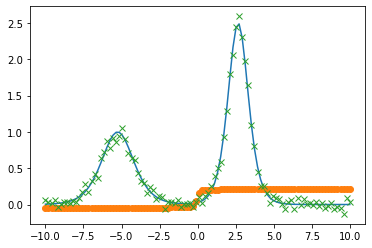

In [80]:
frame = 3
plt.plot(x, u[frame, :])
plt.plot(x, prediction.reshape(x_grid.shape)[frame, :], 'o')
plt.plot(x, y.reshape(x_grid.shape)[frame, :], 'x')

In [102]:
w = jnp.minimum(jnp.abs(y - 0.1 * jnp.std((y - prediction))) / jnp.sqrt((prediction - y)**2), 1.0)

In [110]:
jnp.count_nonzero(w != 1)

DeviceArray(724, dtype=int32)

In [81]:
w =  jnp.minimum(jnp.var((prediction - y)) /  (prediction - y)**2, 1.0).squeeze()
X_prime = jnp.sqrt(jnp.diag(w)) @ theta
y_prime = jnp.sqrt(jnp.diag(w)) @ dt
jnp.linalg.lstsq(X_prime, y_prime)

(DeviceArray([[ 5.2785478e-04],
              [-4.4956490e-02],
              [-1.4001595e-02],
              [ 6.4879016e-04],
              [ 9.7111631e-03],
              [-5.3433657e-01],
              [ 8.6768165e-02],
              [-1.9318075e-03],
              [-5.8355425e-02],
              [-8.5917473e-02],
              [ 2.1444774e-01],
              [ 1.4540337e-02]], dtype=float32),
 DeviceArray([1.9920852e-05], dtype=float32),
 DeviceArray(9, dtype=int32),
 DeviceArray([1.0551062e+02, 2.9447819e+01, 1.2778671e+01, 5.4237161e+00,
              3.5937641e+00, 2.1354153e+00, 2.4554242e-01, 2.6535019e-02,
              1.3614966e-02, 7.3250532e-03, 9.2614640e-04, 2.5605233e-04],            dtype=float32))

In [85]:
jnp.mean(w)

DeviceArray(0.86126435, dtype=float32)

DeviceArray([1.        , 1.        , 1.        , 1.        , 1.        ,
             1.        , 1.        , 1.        , 1.        , 1.        ,
             1.        , 1.        , 1.        , 1.        , 0.9990425 ,
             1.        , 0.66739833, 0.4784665 , 0.38524625, 0.28060547,
             0.31838733, 0.28260362, 0.3587472 , 0.34575677, 0.41528493,
             0.5938412 , 0.8743121 , 1.        , 1.        , 1.        ,
             1.        , 1.        , 1.        , 1.        , 1.        ,
             1.        , 1.        , 1.        , 1.        , 1.        ,
             1.        , 1.        , 1.        , 1.        , 1.        ,
             1.        , 1.        , 1.        , 1.        , 1.        ,
             0.58749926, 0.40879962, 0.18466647, 0.11688931, 0.07882361,
             0.06008316, 0.06335041, 0.09427799, 0.12903893, 0.24168971,
             0.6500537 , 1.        , 1.        , 1.        , 1.        ,
             1.        , 1.        , 1.        , 1.